In [1]:
import pickle
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def load_file(filename):
    with open(filename,'rb') as f:
        return pickle.load(f)

In [2]:
loaded = []
for i in range(5):
    loaded.extend(load_file(f"C:\\Users\\Andrzej\\Desktop\\2send_1\\Space testing\\mediumSAM\\medium_SAM_optimized_{i}"))
    

In [3]:
def parse_file(filename):
    with open(filename,'r') as file:
        result = []
        lines = file.readlines()
        for i,line in enumerate(lines):
            if line[0]=='{':
                result.append((ast.literal_eval(line),float(lines[i+1].split(' ')[-1])))
        return result

In [4]:
def parse_all(filename,files_number:int=10):
    result=[]
    #result.extend(parse_file(filename+'.txt'))
    for i in range(files_number):
        result.extend(parse_file(filename+'_'+str(i)+'.txt'))
    return result

In [5]:
result = parse_all("C:\\Users\\Andrzej\\Desktop\\2send_1\\Space testing\\mediumSAM\\medium_SAM_optimized",5)
result=list(filter(lambda x: x[1]<1053882, result))
# result = []
# for i in range(4):
#     with open(f"PCA\\dump_older_{i}","rb") as file:
#         result.extend(pickle.load(file))
# result = list(filter(lambda x: x[1]<10000,result))
# len(result)

In [6]:
frame = pd.DataFrame.from_dict(list(map(lambda x: x[0],result)))

In [8]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
x=standard_scaler.fit_transform(frame.values)
normalised_coeffs = pd.DataFrame(x,columns=frame.columns)

In [10]:
x.shape

(662, 9)

In [82]:
from sklearn.decomposition import PCA
pca = PCA(n_components=9)
principalComponents_coeffs = pca.fit_transform(x)
PC_frame = pd.DataFrame(data = principalComponents_coeffs)
PC_frame
print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))


Explained variation per principal component: [0.41105777 0.21359597 0.1409701  0.09868197 0.04891782 0.03405955
 0.03319711 0.0163653  0.00315441]


In [40]:
print(pca.components_[0])
print(pca.components_[1])
print(pca.components_[2])
print(pca.components_[3])

[ 0.03007172  0.4716126   0.11002957 -0.40180304 -0.48645089 -0.09808383
  0.40315436 -0.31353677 -0.30988934]
[ 0.39980497 -0.01309896  0.57504597 -0.12331372 -0.06897946  0.60183856
  0.11430675  0.30862914  0.13716588]
[ 6.59347329e-01 -4.01504990e-05 -4.27984080e-01 -2.79364232e-01
 -1.36932556e-01 -3.15821695e-01 -7.94485951e-02  4.18802562e-01
  6.20065953e-02]
[-0.14491785  0.17721954 -0.09215444 -0.35120468 -0.22421726  0.13435929
 -0.40460766 -0.25562114  0.71998581]


In [41]:
def from_dicts_to_PCA(dicts):
    data_frame = pd.DataFrame.from_dict(dicts)
    scaled=standard_scaler.transform(data_frame.values)
    return pd.DataFrame(data = pca.transform(scaled))

In [42]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(kernel="rbf", n_components=9, fit_inverse_transform=True)
principalComponents_coeffs = kpca.fit_transform(x)
PC_frame = pd.DataFrame(data = principalComponents_coeffs)


In [43]:
plot_data = [("Cost Function",list(map(lambda x: x[1],result)))]+[(name,list(map(lambda x: x[0][name],result))) for name in result[0][0].keys()]+[("Neg/Straight", list(map(lambda x: x[0]["inhibition_coef"]/max(0.01,x[0]["straight_coef"]),result)))]

In [44]:
def get_rest_closest(p1,p2):
    distances=list(map(lambda x: (x[0]-p1)**2+(x[1]-p2)**2,PC_frame.to_numpy()))
    closest_distances=list(filter(lambda x: x<1,distances))
    if len(closest_distances)<3:
        closest_distances=sorted(distances)[:3]
    indices=[distances.index(i) for i in closest_distances]
    bests = PC_frame.to_numpy()[indices][:,2:]
    weights = [1/i**0.5 for i in closest_distances]
    return list(sum(weight*best for weight,best in zip(weights,bests))/sum(weights))

def get_rest_random_from_best(p1,p2,amount=len(result)):
    distances=list(map(lambda x: x[1], result))
    closest_distances=distances[:amount]
    indices=[distances.index(i) for i in closest_distances]
    bests = PC_frame.to_numpy()[indices][:,2:]
    weights = [random.random() for i in closest_distances]
    return list(sum(weight*best for weight,best in zip(weights,bests))/sum(weights))



def generate_values_from_PCA(p1,p2,result,pca):
    distances=list(map(lambda x: (x[0]-p1)**2+(x[1]-p2)**2,PC_frame.to_numpy()))
    # closest_distances=list(filter(lambda x: x<1,distances))
    # if len(closest_distances)<3:
    #     closest_distances=sorted(distances)[:3]
    closest_distances=[min(distances)]
    indices=[distances.index(i) for i in closest_distances]
        
    #costs=list(map(lambda x: x[1],result))

    #vector = [p1,p2]+get_rest_closest(p1,p2)
    vector = [p1,p2]+get_rest_random_from_best(p1,p2)
    d = {name:max(0,value) for name,value in zip(result[0][0].keys(),list(standard_scaler.inverse_transform(pca.inverse_transform(np.array(vector)))))}
    return d

In [45]:

x = np.arange(-5.0,5.001, 0.1)
y = np.arange(-5.0,5.001, 0.1)
y=-y
X, Y = np.meshgrid(x, y)


# values = {}
# for i,j in zip(X.flatten(),Y.flatten()):
#         values[(i,j)]=generate_values_from_PCA(i,j,result,pca,)
#         values[(i,j)]["Neg/Straight"]=values[(i,j)]["inhibition_coef"]/max(0.01,values[(i,j)]["straight_coef"])

In [46]:
for i,j in zip(X.flatten(),Y.flatten()):
    del values[(i,j)]["Neg/Straight"]
pickle.dump([value for k,value in values.items()],open("mediumSAM\\ev","wb"))

In [47]:
# values_with_dist=[]
# for i in range(5):
#     values_with_dist.extend(pickle.load(open(f"mediumSAM\\ev_value_{i}","rb")))
#_values_flat=list(map(values_with_dist[0]))
# values=copy.deepcopy(values_backup)
# for i,j in zip(X.flatten(),Y.flatten()):
#     values[(i,j)]["Cost Function"]=values_with_dist[_values_flat.index(values[(i,j)])][1]
#     values[(i,j)]["Neg/Straight"]=values[(i,j)]["inhibition_coef"]/max(0.01,values[(i,j)]["straight_coef"])

In [12]:
#pickle.dump(values,open("mediumSAM\\_2dmap_dump","wb"))
values=pickle.load(open("mediumSAM\\_2dmap_dump","rb"))

In [49]:
sorted([(i,x["inertia"]) for i,x in enumerate(sorted([v for k,v in values.items()],key=lambda x: x['Cost Function'])[:100])],key=lambda x: x[1])

[(94, 4.518998661744949),
 (50, 4.5473478278597135),
 (47, 4.554496137092196),
 (35, 4.57477938548476),
 (81, 4.582996640153555),
 (36, 4.583494916912197),
 (93, 4.585387108376087),
 (45, 4.607317202749131),
 (57, 4.610959436140313),
 (34, 4.612659420592556),
 (88, 4.618174368465847),
 (62, 4.6306576766028975),
 (97, 4.633502126037563),
 (82, 4.639425320806292),
 (77, 4.643210501936382),
 (73, 4.6438203198803345),
 (90, 4.653044058028178),
 (79, 4.655427770404375),
 (86, 4.656855665306602),
 (58, 4.661496224423763),
 (95, 4.6689568316462555),
 (70, 4.672113468674348),
 (66, 4.680408957041068),
 (84, 4.698433151726005),
 (65, 4.705154444151437),
 (74, 4.715562910063431),
 (54, 4.718660052832748),
 (76, 4.7279178986845976),
 (61, 4.728914979675687),
 (60, 4.73107173290437),
 (53, 4.745487906568105),
 (96, 4.747744667950177),
 (49, 4.753732193100547),
 (63, 4.764453274612876),
 (92, 4.76685455347137),
 (71, 4.7671075796304),
 (99, 4.774688692344048),
 (80, 4.778707440087821),
 (44, 4.7801

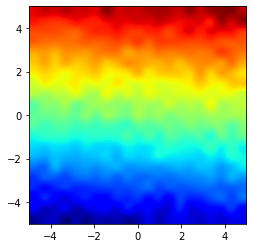

In [50]:
Z=np.array([[values[(X[i,j],Y[i,j])]["pos_range"] for j in range(21)] for i in range(21)])
im = plt.imshow(Z, cmap=plt.cm.get_cmap('jet'), extent=(-5,5,-5,5), interpolation='catrom')

In [51]:
N=300
from matplotlib.colors import ListedColormap
vals = np.ones((N, 4))
vals[:, 0] =0.2
vals[:, 1] =0.0
vals[:, 2] =0.0
vals[:, 3] =np.linspace(0, 0.9, N)**5
ConcentrationMap = ListedColormap(vals)

In [52]:
def generate_plots(data_frame,plot_data, save=False):
    for title,colors in plot_data:
        plt.figure()
        plt.figure(figsize=(10,10))
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=14)
        plt.xlabel('Principal Component - 1',fontsize=10)
        plt.ylabel('Principal Component - 2',fontsize=10)

        print(min(colors),max(colors))
        if title!="Cost Function":
            try:
                Z=np.array([[values[(X[i,j],Y[i,j])][title] for j in range(X.shape[0])] for i in range(X.shape[0])])
                plt.imshow(Z, cmap=plt.cm.get_cmap('jet'), extent=(-5,5,-5,5), interpolation='bilinear',vmin=min(colors),vmax=max(colors))
            except KeyError:
                pass
            Z=np.array([[values[(X[i,j],Y[i,j])]["Cost Function"] for j in range(X.shape[0])] for i in range(X.shape[0])])
            Z = (np.minimum(400,Z)/100)**6
            plt.imshow(np.max(Z)-Z, cmap=ConcentrationMap, extent=(-5,5,-5,5), interpolation='bilinear')
        else:
            try:
                Z=np.array([[values[(X[i,j],Y[i,j])][title] for j in range(X.shape[0])] for i in range(X.shape[0])])
                print(type(Z[0]))
                plt.imshow(Z, cmap=plt.cm.get_cmap('jet'), extent=(-5,5,-5,5), interpolation='bilinear',vmin=min(colors),vmax=max(colors))
            except KeyError:
                pass
        plt.title(title)
        plot=plt.scatter(data_frame.loc[:, 0], data_frame.loc[:, 1],c=colors,edgecolors='white',s = 50,cmap="jet")
        plt.colorbar(plot)
        if save:
            plt.savefig(title+".png")
        plt.show()


In [91]:
PC_frame = PC_frame[PC_frame[1]<5]
# print(PC_frame.loc[PC_frame[1]>5])
# for _,l in plot_data:
#     l.pop(566)
#     l.pop(614)

In [108]:
import matplotlib
cmap_reversed = matplotlib.cm.get_cmap('magma').reversed()

In [147]:
newcolors = cmap_reversed(np.linspace(0, 1, 256)**0.6)
newcmp = ListedColormap(newcolors)

0.5597992856424251 0.9291467427723507


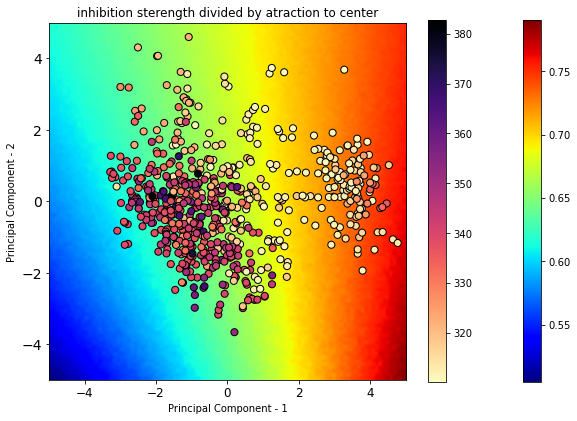

In [167]:
#plt.figure()
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1',fontsize=10)
plt.ylabel('Principal Component - 2',fontsize=10)
title,colors = plot_data[-1]
print(min(colors),max(colors))
Z=np.array([[values[(X[i,j],Y[i,j])][title] for j in range(X.shape[0])] for i in range(X.shape[0])])
plot=plt.imshow(Z, cmap=plt.cm.get_cmap('jet'), extent=(-5,5,-5,5), interpolation='bilinear')
plt.colorbar(plot, shrink=0.666)
plt.title("inhibition sterength divided by atraction to center")
plot=plt.scatter(PC_frame.loc[:, 0], PC_frame.loc[:, 1],c=plot_data[0][1],edgecolors='black',s = 50,cmap="magma_r")
plt.colorbar(plot, shrink=0.666)
#plt.show()
#plt.savefig(f"scatter {}")
plt.savefig("neg_straight.eps")

In [54]:
sorted([(k,v) for k,v in values.items()],key=lambda x: x[1]["Cost Function"])[:1]

[((2.7999999999999723, 0.6000000000000156),
  {'pos_range': 94.6139871413999,
   'age_coef': 0.0898168675836104,
   'inhibition_coef': 1.9380879937972648,
   'attraction_coef': 0,
   'neg_range': 45.504265466109196,
   'straight_coef': 2.6968647751699355,
   'inertia': 4.968567709663606,
   'peak_coef': 0.7007414561054597,
   'age_cut_off_coef': 1.3488342990477376,
   'Cost Function': 309.8205721145285,
   'Neg/Straight': 0.7186448544403349})]

0.01 5.424145679978925


<Figure size 432x288 with 0 Axes>

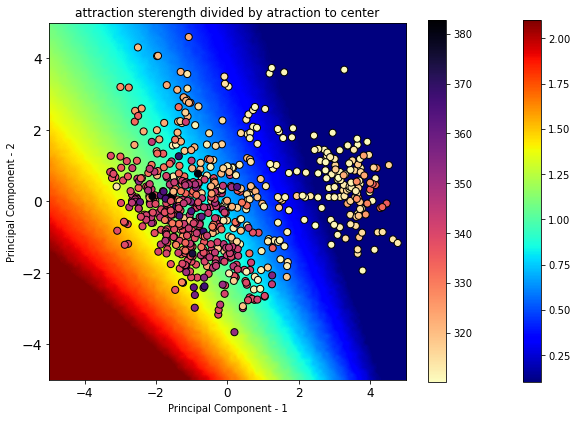

In [172]:
plt.figure()
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1',fontsize=10)
plt.ylabel('Principal Component - 2',fontsize=10)
title,colors = plot_data[4]
title2,colors2 = plot_data[6]
print(min(colors),max(colors))
Z=np.array([[values[(X[i,j],Y[i,j])][title] for j in range(X.shape[0])] for i in range(X.shape[0])])/np.array([[values[(X[i,j],Y[i,j])][title2] for j in range(X.shape[0])] for i in range(X.shape[0])])
plot=plt.imshow(Z, cmap=plt.cm.get_cmap('jet'), extent=(-5,5,-5,5), interpolation='bilinear',vmax=2.1,vmin=0.1)
plt.colorbar(plot, shrink=0.666)
plt.title("attraction sterength divided by atraction to center")
plot=plt.scatter(PC_frame.loc[:, 0], PC_frame.loc[:, 1],c=plot_data[0][1],edgecolors='black',s = 50,cmap="magma_r")
plt.colorbar(plot, shrink=0.666)
plt.savefig("pos_straight.eps")

0.5597992856424251 0.9291467427723507


FileNotFoundError: [Errno 2] No such file or directory: 'cmap_tests\\3\\map scatter viridis.png'

<Figure size 432x288 with 0 Axes>

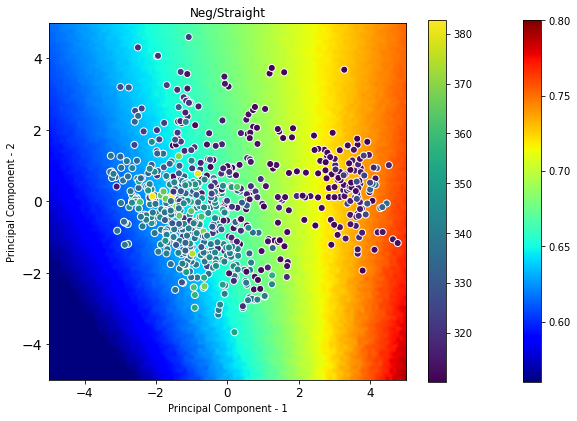

In [137]:
plt.figure()
import itertools
for cmap_scatter in ['viridis', 'plasma', 'inferno', 'magma', 'cividis']+['ocean', 'gist_earth', 'terrain',
                      'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap',
                      'cubehelix', 'brg', 'gist_rainbow', 'rainbow', 'jet',
                      'turbo', 'nipy_spectral', 'gist_ncar']+['twilight', 'twilight_shifted', 'hsv']:
    for s in ['',"_r"]:
        cmap_scatter+=s
        plt.figure(figsize=(10,10))
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=14)
        plt.xlabel('Principal Component - 1',fontsize=10)
        plt.ylabel('Principal Component - 2',fontsize=10)
        title,colors = plot_data[-1]
        print(min(colors),max(colors))
        Z=np.array([[values[(X[i,j],Y[i,j])][title] for j in range(X.shape[0])] for i in range(X.shape[0])])
        plot=plt.imshow(Z, cmap="jet", extent=(-5,5,-5,5), interpolation='bilinear',vmin=min(colors),vmax=0.8)
        plt.colorbar(plot, shrink=0.666)
        plt.title(title)
        plot=plt.scatter(PC_frame.loc[:, 0], PC_frame.loc[:, 1],c=plot_data[0][1],edgecolors='white',s = 50,cmap=cmap_scatter)
        plt.colorbar(plot, shrink=0.666)
        #plt.show()
        plt.savefig(f"cmap_tests\\3\\map scatter {cmap_scatter}")
        plt.clf()
        plt.close()

310.0409040360828 382.7208208811769
<class 'numpy.ndarray'>


<Figure size 432x288 with 0 Axes>

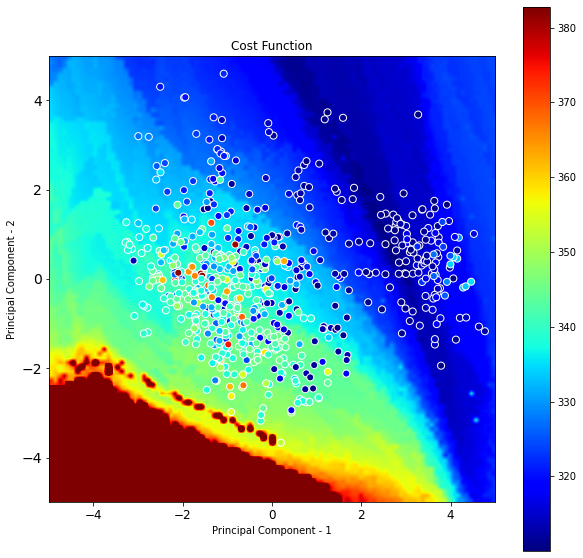

36.44874349563984 167.7183938820731


<Figure size 432x288 with 0 Axes>

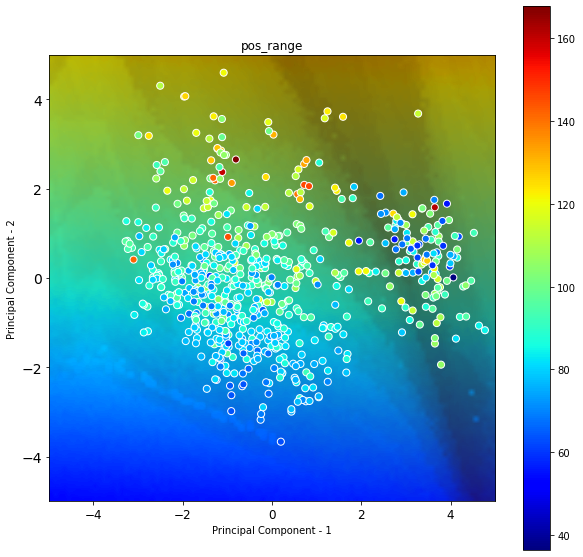

0.01 0.16571884995809472


<Figure size 432x288 with 0 Axes>

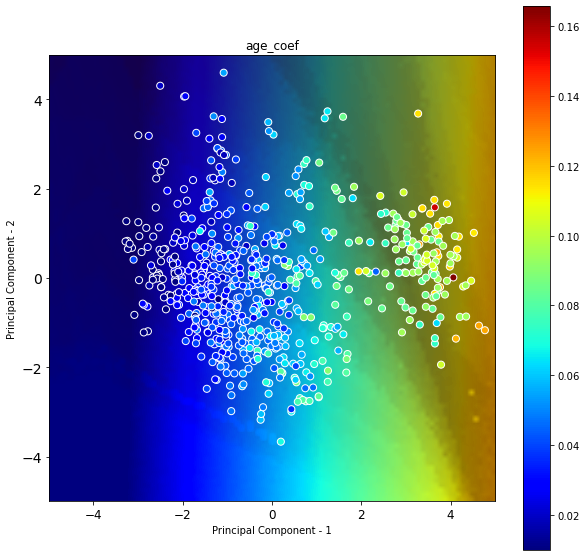

1.1935127306942797 2.6038287624565957


<Figure size 432x288 with 0 Axes>

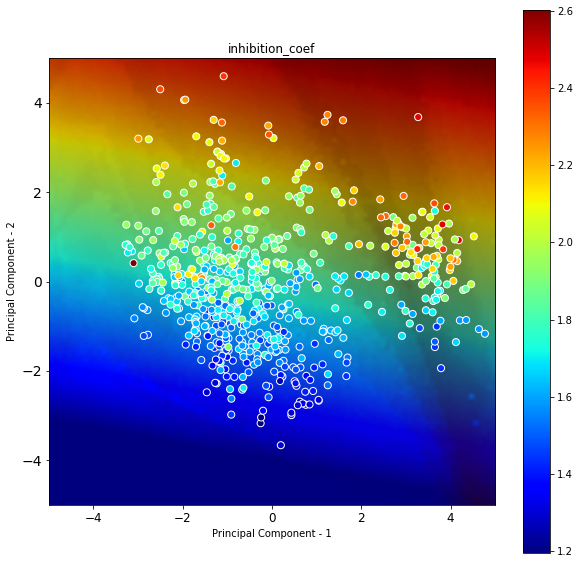

0.01 5.424145679978925


<Figure size 432x288 with 0 Axes>

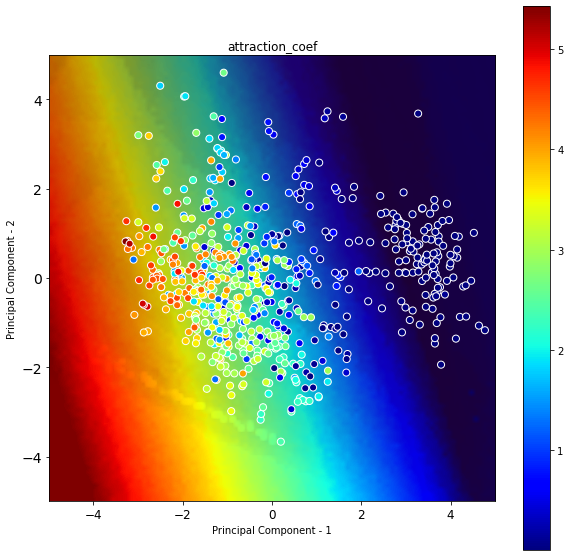

35.83346509073174 77.33140004024446


<Figure size 432x288 with 0 Axes>

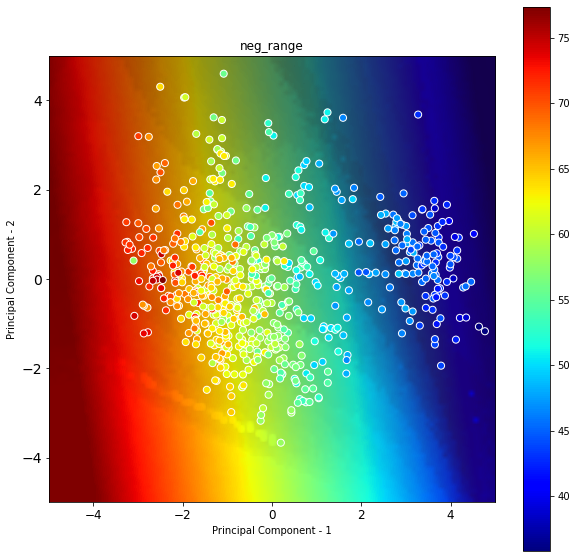

1.9863473903235296 3.998870384755479


<Figure size 432x288 with 0 Axes>

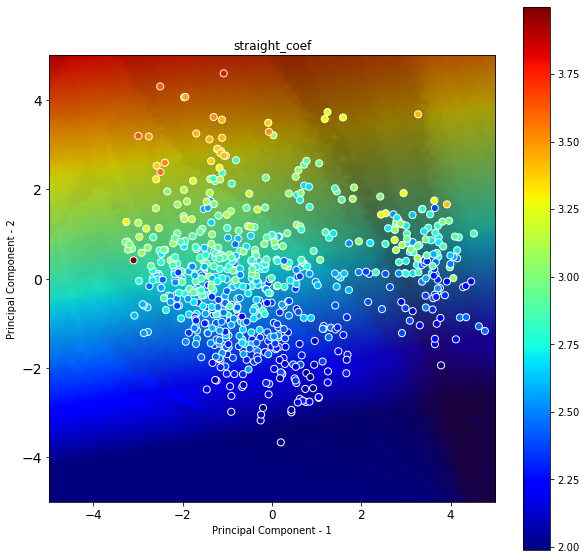

2.3635832781019497 7.036806192054311


<Figure size 432x288 with 0 Axes>

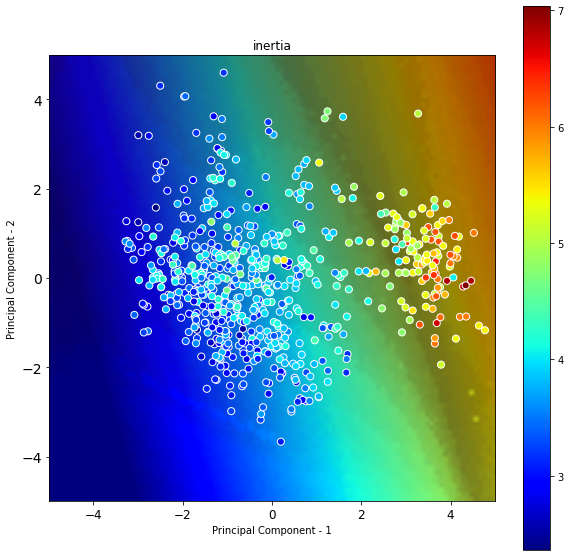

0.41698764245947456 0.99


<Figure size 432x288 with 0 Axes>

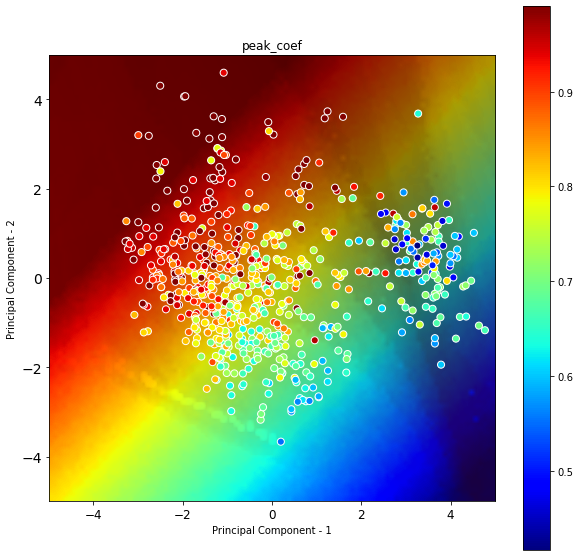

0.7186687726856273 2.993152984057016


<Figure size 432x288 with 0 Axes>

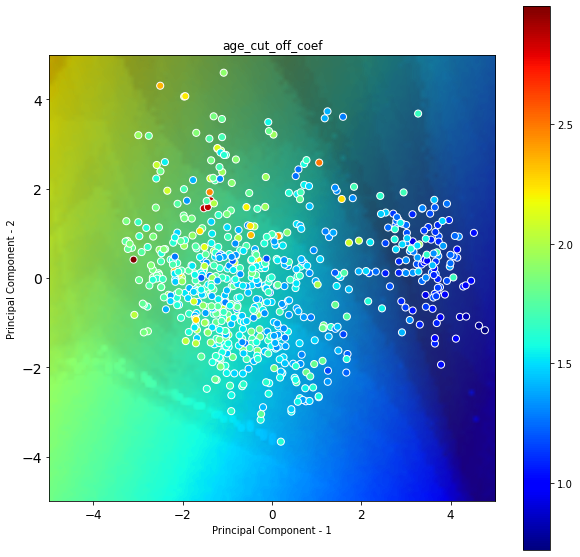

0.5597992856424251 0.9291467427723507


<Figure size 432x288 with 0 Axes>

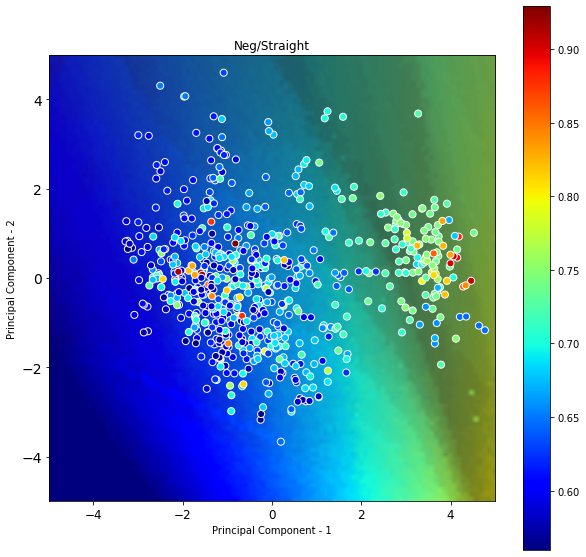

In [97]:
generate_plots(PC_frame,plot_data,save=False)

In [ ]:
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# for title,colors in plot_data:
#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')
#     plot=plt.scatter(PC_frame.loc[:, 0], PC_frame.loc[:, 1], PC_frame.loc[:, 2],c=colors,cmap="jet")

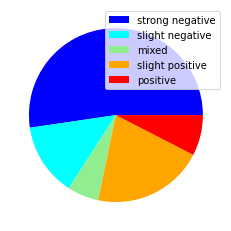

In [15]:
v=[]
sizes = [0,0,0,0,0]
l_values = [x for _,x in values.items()]

for i in range(1):
    sizes = [0,0,0,0,0]
    for r in l_values:
        #weight = 350/r["Cost Function"]
        if r["Cost Function"]>340:
            continue
        #v.append(r['inhibition_coef']/r['attraction_coef'])
        if r['attraction_coef']>0:
            ratio = r['inhibition_coef']/r['attraction_coef']
        else:
            ratio = 1000
        if ratio>2:
            sizes[0]+=1
        elif ratio>1.1:
            sizes[1]+=1
        elif ratio>0.9:
            sizes[2]+=1
        elif ratio>0.5:
            sizes[3]+=1
        else:
            sizes[4]+=1
    plt.pie(sizes,colors=["blue","cyan","lightgreen","orange","red"])  
    plt.legend(["strong negative","slight negative","mixed","slight positive","positive"])
    plt.savefig("pie.svg")

(array([1449., 1981., 1046., 1716., 1212.,  988.,  386.,  188.,   88.,
          36.]),
 array([309.82057211, 316.80993454, 323.79929697, 330.78865939,
        337.77802182, 344.76738424, 351.75674667, 358.74610909,
        365.73547152, 372.72483394, 379.71419637]),
 <BarContainer object of 10 artists>)

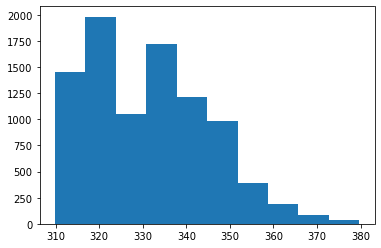

In [18]:
plt.hist([r["Cost Function"] for r in l_values if r["Cost Function"]<380])

In [134]:
#plt.hist([np.log2(min(r['inhibition_coef']/r['attraction_coef'],10000)) for r in l_values if r["Cost Function"]<350],bins=20)
len([x for x in sorted(l_values,key=lambda x: -x["attraction_coef"]/r['inhibition_coef']) if x["Cost Function"]<315])

1124

In [49]:
PC_frame.to_numpy()[[costs.index(i) for i in sorted(costs)][:10]]

array([[ 3.10934478,  0.65540587, -2.2642143 ,  1.38581164,  0.15899038,
        -0.27749598,  0.20323359, -0.1354164 ,  0.06028683],
       [ 2.5411212 ,  0.78056277, -0.96395563, -0.5633489 ,  0.0261668 ,
        -0.94952802, -0.28359019,  0.11630145, -0.1151126 ],
       [ 3.91844087,  1.66409537, -3.75323419,  0.86658438, -0.65033646,
        -0.51656692,  0.01116769,  0.04968302,  0.13137441],
       [ 3.44760709,  0.47199389,  1.18029815,  0.36836127, -0.53179986,
         0.01368973,  1.36246205,  0.07486306,  0.49682204],
       [ 2.46330851, -0.68006484,  0.27176243,  0.70112442,  0.44086831,
         0.42296989, -0.19722639, -0.14294476,  0.01587931],
       [ 3.27290457,  3.68315308, -0.99253876,  1.05070775, -0.29155927,
         1.1582669 ,  0.36046035, -0.00885287,  0.27406652],
       [ 1.83707703,  2.04318612, -0.59353339,  0.74122702,  0.52937048,
        -1.40675108,  1.03845921,  0.01819264,  0.13087642],
       [ 1.24309888,  3.73290047,  0.77283362, -0.71739366, -0

In [52]:
costs=list(map(lambda x: x[1],result))
indices=[costs.index(i) for i in sorted(costs)][:10]

In [50]:
costs=list(map(lambda x: x[1],result))
indices=[costs.index(i) for i in sorted(costs)][:10]
PC_frame.to_numpy()[[costs.index(i) for i in sorted(costs)][:10]]
#PC_frame.to_numpy()[136]
normalised_coeffs.to_numpy()[136]
#standard_scaler.inverse_transform(normalised_coeffs.to_numpy()[136]),standard_scaler.inverse_transform(pca.inverse_transform(PC_frame.to_numpy()[136]))

standard_scaler.inverse_transform(pca.inverse_transform(PC_frame.to_numpy()[136]))

array([9.74632901e+01, 3.87030212e-02, 1.56536933e+00, 2.11849267e-01,
       5.50031685e+01, 2.33053343e+00, 3.72110908e+00, 7.77117939e-01,
       1.70818925e+00])

In [36]:
standard_scaler.inverse_transform(pca.inverse_transform(PC_frame.to_numpy()[136]))

ValueError: shapes (2,) and (9,9) not aligned: 2 (dim 0) != 9 (dim 0)

In [140]:
standard_scaler.inverse_transform(pca.inverse_transform(PC_frame.to_numpy()[136]))

array([81.37448567,  0.08212871,  2.15177346,  1.19294525, 51.067904  ,
        2.30534378,  4.83889373,  0.51237232,  1.31133533])

In [51]:
list(PC_frame.to_numpy()[136][2:])

[1.3187150560061505,
 0.7236005965892676,
 0.47154881573201723,
 -0.02894475638421374,
 -0.7578834253411882,
 0.2061173430123798,
 -0.23550070585177277]

In [142]:
def get_range_index(index,density):
    return list(np.linspace(PC_frame.to_numpy()[:,index].min(),PC_frame.to_numpy()[:,index].max(),density))

In [76]:
import random
costs=list(map(lambda x: x[1],result))
indices=[costs.index(i) for i in sorted(costs)][:10]
bests = PC_frame.to_numpy()[indices][:,3:]
weights = [random.random() for i in range(bests.shape[0])]
rest = sum(weight*best for weight,best in zip(weights,bests))
list(rest)

[2.684546846294798,
 0.008506160892445075,
 -1.912501704003503,
 1.4060338743415413,
 0.12421481836439932,
 0.6275285974918614]

In [ ]:
import itertools
import random
density = 20
def generate_values(p1,p2,result,):
    costs=list(map(lambda x: x[1],result))
    indices=[costs.index(i) for i in sorted(costs)][:10]
    bests = PC_frame.to_numpy()[indices][:,3:]
    weights = [random.random() for i in range(bests.shape[0])]
    rest = sum(weight*best for weight,best in zip(weights,bests))
    vector = [p1,p2]+list(rest)
    d = {name:max(0,value) for name,value in zip(result[0][0].keys(),list(standard_scaler.inverse_transform(pca.inverse_transform(np.array(vector)))))}
    return d


In [143]:
# import itertools
# import random
# density = 20
# with open("to_test","wb") as file:
#     dicts=[]
#     for a,b,c in list(itertools.product(get_range_index(0,density),get_range_index(1,density),get_range_index(2,density))):
#         for index in [136, 39, 135, 70]:
#             for i in range(10):
#                 vector = [a,b,c]+list(i * (1+(random.random()-0.5)*0.1) for i in PC_frame.to_numpy()[index][3:])
#                 d = {name:max(0,value)*(1+(random.random()-0.5)*0.02) for name,value in zip(result[0][0].keys(),list(standard_scaler.inverse_transform(pca.inverse_transform(np.array(vector)))))}
#                 dicts.append(d)
#     pickle.dump(dicts,file)
#     print(len(dicts))
            

In [152]:
result = []
for i in range(4):
    with open(f"PCA\\dump_older_{i}","rb") as file:
        result.extend(pickle.load(file))
result = list(filter(lambda x: x[1]<255,result))
print(len(result))
min(result,key=lambda x: x[1])

435


({'pos_range': 85.18036381896513,
  'age_coef': 0.07600021357392359,
  'inhibition_coef': 2.2732400378211057,
  'attraction_coef': 1.5311538467468093,
  'neg_range': 52.98633272180075,
  'straight_coef': 2.38673112236469,
  'inertia': 5.087212821765796,
  'peak_coef': 0.5581165351039549,
  'age_cut_off_coef': 1.2982765490651127},
 247.1239257581873)

In [21]:
optimized=parse_all("C:\\Users\\Andrzej\\Desktop\\2send_1\\Space testing\\PCA\\optimalization\\dump_old_max_",files_number=100)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Andrzej\\Desktop\\2send_1\\Space testing\\PCA\\optimalization\\dump_old_max_.txt'

<Figure size 432x288 with 0 Axes>

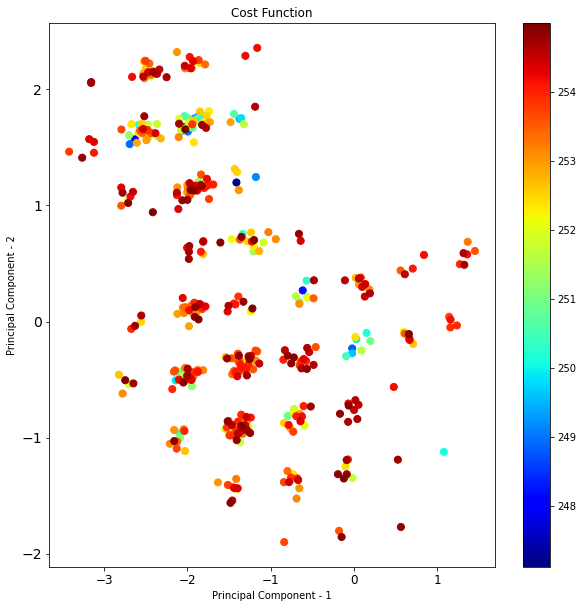

In [153]:
generate_plots(from_dicts_to_PCA(list(map(lambda x: x[0],result))),[("Cost Function",list(map(lambda x: x[1],result)))])

In [19]:
import pickle
space_exploration = []
for i in range(5):
    print(len(pickle.load(open(f"space_exploration\\dump_mediumSAM_max_{i}","rb"))))
    space_exploration.extend(pickle.load(open(f"space_exploration\\dump_mediumSAM_max_{i}","rb")))

20000
20000
20000
20000
20000


In [28]:
# space_exploration.sort(key=lambda x: x[1])
# pickle.dump(space_exploration,open("space_exploration\\dump_mediumSAM","wb"))

In [59]:
import pickle
space_exploration = []
for i in range(10):
    print(len(pickle.load(open(f"space_exploration\\opt\\dump_mediumSAM_opt_{i}","rb"))))
    space_exploration.extend(pickle.load(open(f"space_exploration\\opt\\dump_mediumSAM_opt_{i}","rb")))
len(space_exploration)

34
34
33
35
34
16
16
16
16
16


250

In [52]:
max(space_exploration,key=lambda x: x[1])


({'pos_range': 138.2535,
  'age_coef': 0.08000000000000004,
  'inhibition_coef': 1.6231578947368424,
  'attraction_coef': 0.23526315789473684,
  'neg_range': 47.36660526315789,
  'straight_coef': 2.6838769798657474,
  'inertia': 2.3,
  'peak_coef': 0.3862286681399483,
  'age_cut_off_coef': 1.526399745774119},
 319.7577310501274)